## 2. Basic Simulator - basic_provider

---

In [20]:
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicSimulator
from qiskit import transpile

from qiskit.visualization import plot_histogram, plot_distribution
import matplotlib.pyplot as plt

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor':   '#282c34',  
    'axes.facecolor':     '#1e1e1e',    
    'grid.color':         '#444444',

    'figure.figsize': (10, 6),
    'figure.dpi': 150
})    

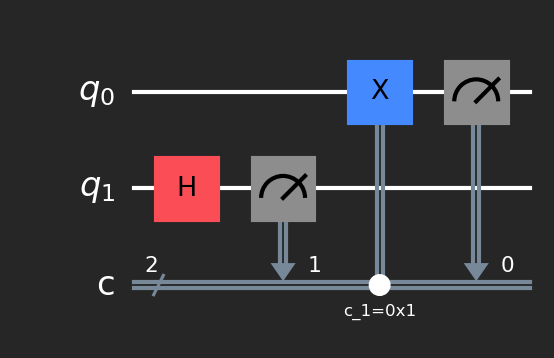

In [3]:
qc = QuantumCircuit(2,2)
qc.h(1)
qc.measure(1,1)
qc.x(0).c_if(1,1)
qc.measure(0,0)
qc.draw()

In [11]:
Basic_simulator = BasicSimulator()

counts = Basic_simulator.run(qc, shots = 1024).result().get_counts()

print(counts)

{'11': 537, '00': 487}


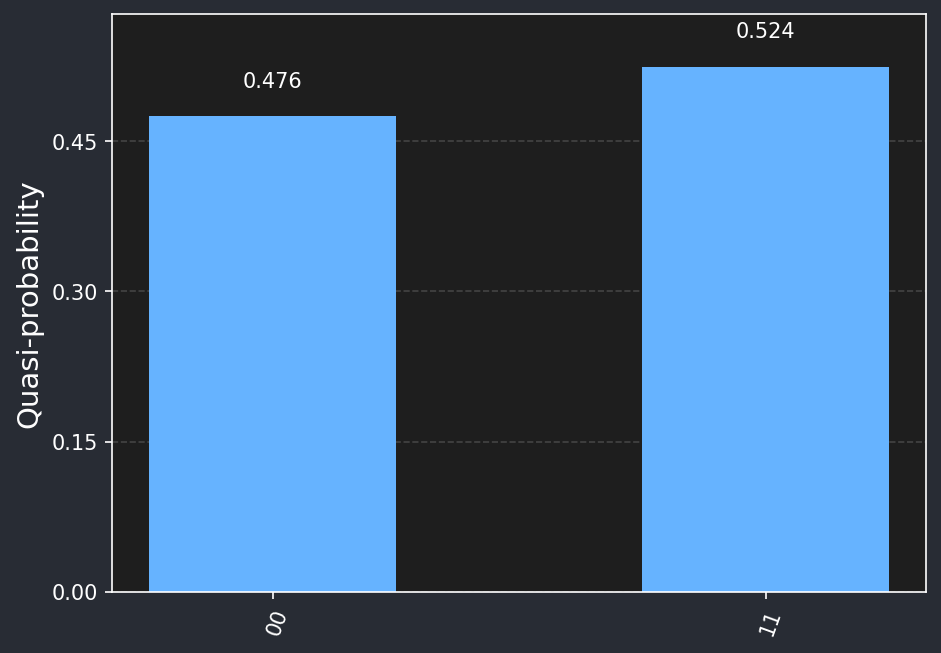

In [16]:
plot_distribution(counts, color = ['#66b3ff'])

In [18]:
job = Basic_simulator.run(qc, shots=10, memory=True)

result = job.result()

samples = result.get_memory()

print(samples)

['11', '00', '00', '00', '11', '11', '11', '00', '00', '11']


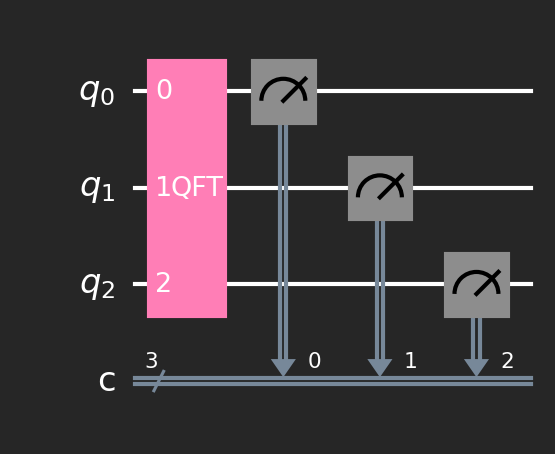

In [19]:
from qiskit.circuit.library import QFT

qc = QuantumCircuit(3,3)
qc.append(QFT(3), range(3))
qc.measure(range(3),range(3))
qc.draw()

> Com o Basic Simulator sempre temos que traspilar antes de rodar

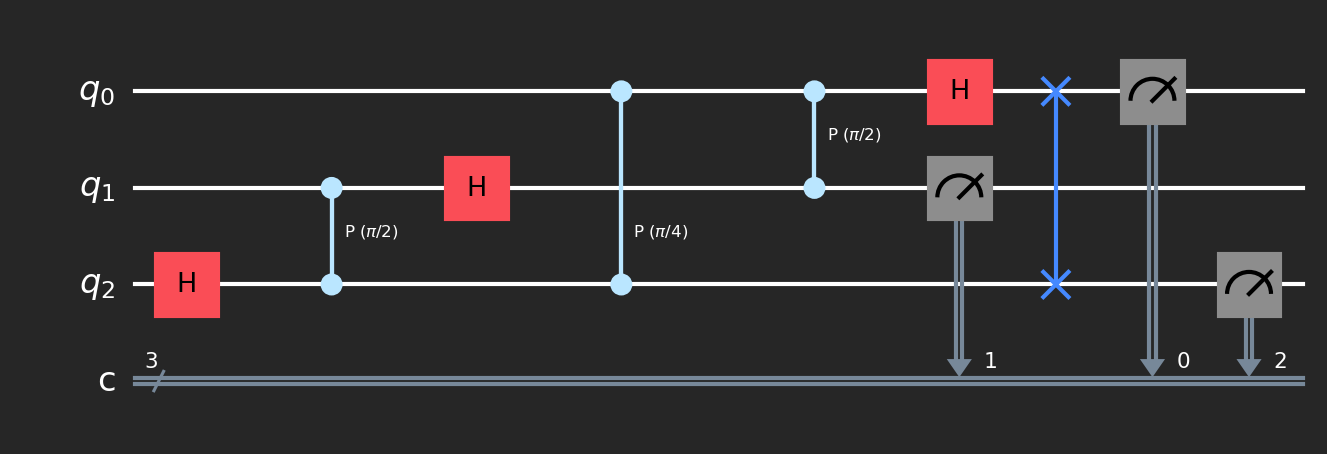

In [21]:
qc_basic = transpile(qc, backend=Basic_simulator)
qc_basic.draw()

In [22]:
result = Basic_simulator.run(qc_basic, shots=1024).result()
counts = result.get_counts()
print(counts)

{'110': 146, '111': 126, '010': 105, '000': 131, '011': 122, '100': 136, '001': 134, '101': 124}
